## Import the libraries

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

## Load the dataset

In [117]:
dataset=pd.read_csv("Advertising.csv")


## Data Validation

Dataset Information

In [118]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


Summary Statistics

In [119]:
dataset.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


Missing Values

In [120]:
dataset.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Duplicate Rows

In [121]:
dataset.duplicated().sum()

np.int64(0)

## Model 1: TV => Sales

### Feature Selection

In [122]:
X=dataset.iloc[:,[0]].values
y=dataset.iloc[:,-1].values

### Spliting Training set and Testing set

In [123]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

### Training the Model on the Training set

In [124]:
reg=LinearRegression()
reg.fit(X_train,y_train)  

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.05]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1105.2]


### Predicting the Test set Result

In [125]:
y_pred=reg.predict(X_test)

### Training Set Visualization

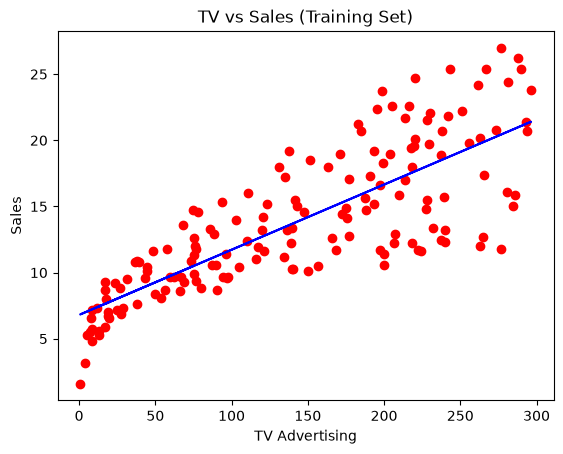

In [126]:
plt.scatter(X_train,y_train,color='red')
plt.plot(X_train,reg.predict(X_train),color='blue')
plt.title("TV vs Sales (Training Set)")
plt.xlabel("TV Advertising")
plt.ylabel("Sales")

plt.show()

### Test Set Visualization

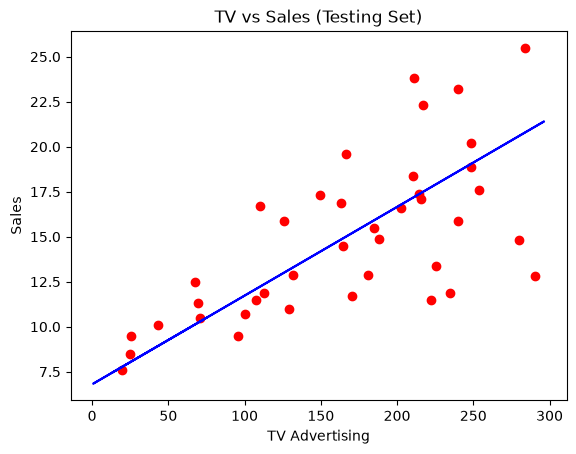

In [127]:
plt.scatter(X_test,y_test,color='red')
plt.plot(X_train,reg.predict(X_train),color='blue')
plt.title("TV vs Sales (Testing Set)")
plt.xlabel("TV Advertising")
plt.ylabel("Sales")

plt.show()

### Model Evaluation

In [128]:
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 10.85934532560827
RMSE: 3.2953520791575928
R²: 0.41535307148347855


## Model 2: Radio => Sales

### Feature Selection

In [129]:
X=dataset.iloc[:,[1]].values
y=dataset.iloc[:,-1].values

### Spliting Training set and Testing set

In [130]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

### Training the Model on the Training set

In [131]:
reg=LinearRegression()
reg.fit(X_train,y_train)  

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.2]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,9.134
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[192.18]


### Predicting the Test set Result

In [132]:
y_pred=reg.predict(X_test)

### Training Set Visualization

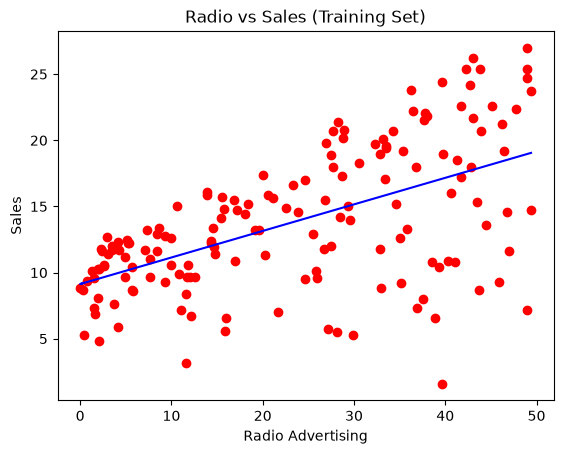

In [133]:
plt.scatter(X_train,y_train,color='red')
plt.plot(X_train,reg.predict(X_train),color='blue')
plt.title("Radio vs Sales (Training Set)")
plt.xlabel("Radio Advertising")
plt.ylabel("Sales")

plt.show()

### Testing Set Visualization

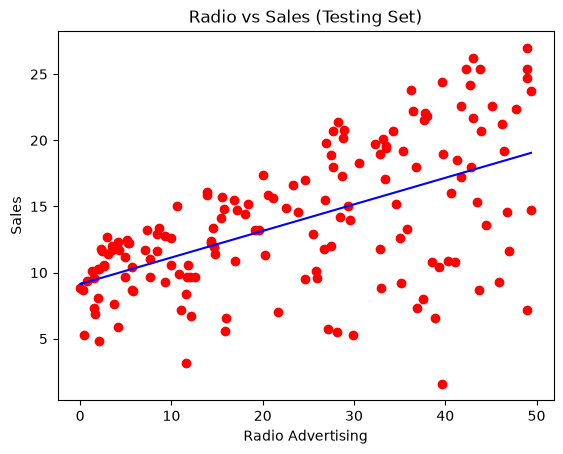

In [134]:
plt.scatter(X_train,y_train,color='red')
plt.plot(X_train,reg.predict(X_train),color='blue')
plt.title("Radio vs Sales (Testing Set)")
plt.xlabel("Radio Advertising")
plt.ylabel("Sales")

plt.show()

### Model Evaluation

In [135]:
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 11.940633086605168
RMSE: 3.455522114906106
R²: 0.35713855215895074


## Model 3: Newspaper => Sales

### Feature Selection

In [136]:
X=dataset.iloc[:,[2]].values
y=dataset.iloc[:,-1].values

### Spliting Training set and Testing set

In [137]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

### Training the Model on the Training set

In [138]:
reg=LinearRegression()
reg.fit(X_train,y_train)  

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.07]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,11.71
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[265.84]


### Predicting the Test set Result

In [139]:
y_pred=reg.predict(X_test)

### Training Set Visualization

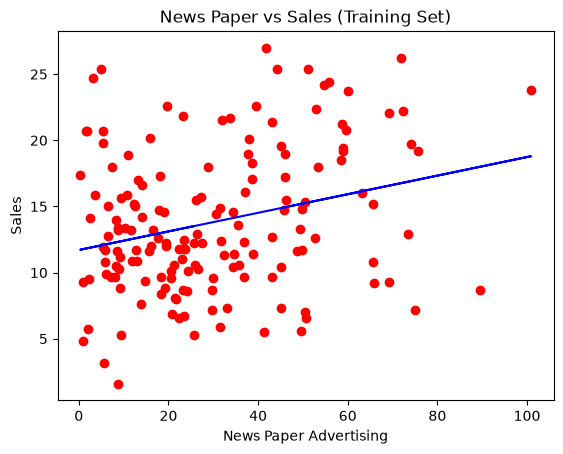

In [140]:
plt.scatter(X_train,y_train,color='red')
plt.plot(X_train,reg.predict(X_train),color='blue')
plt.title("News Paper vs Sales (Training Set)")
plt.xlabel("News Paper Advertising")
plt.ylabel("Sales")

plt.show()

### Testing Set Visualization

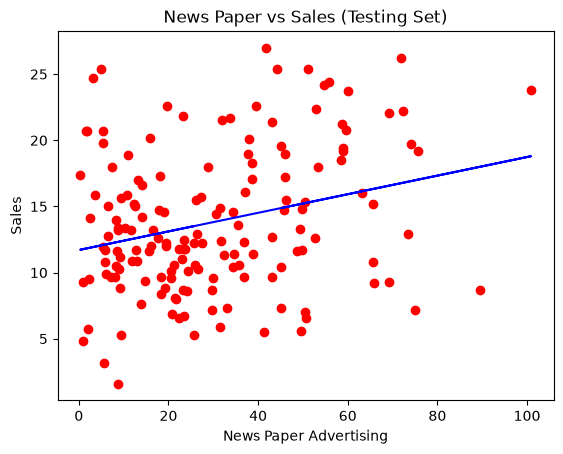

In [141]:
plt.scatter(X_train,y_train,color='red')
plt.plot(X_train,reg.predict(X_train),color='blue')
plt.title("News Paper vs Sales (Testing Set)")
plt.xlabel("News Paper Advertising")
plt.ylabel("Sales")

plt.show()

### Model Evaluation

In [142]:
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 21.855358682807495
RMSE: 4.674971516791038
R²: -0.17665180933129299


# Model Comparison

## Comparison Table

In [146]:
comparison = pd.DataFrame({
    "Feature": ["TV", "Radio", "Newspaper"],
    "MSE": [10.85934532560827, 11.940633086605168, 21.855358682807495],
    "RMSE": [3.2953520791575928, 3.455522114906106, 4.674971516791038],
    "R2": [0.41535307148347855, 0.35713855215895074, -0.17665180933129299]
})

comparison

,Feature,MSE,RMSE,R2
0,TV,10.859345,3.295352,0.415353
1,Radio,11.940633,3.455522,0.357139
2,Newspaper,21.855359,4.674972,-0.176652


## R² Score Comparison

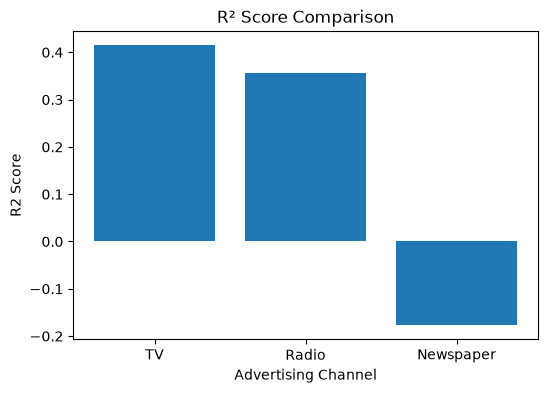

In [147]:
features = comparison["Feature"]
r2 = comparison["R2"]

plt.figure(figsize=(6,4))
plt.bar(features, r2)

plt.title("R² Score Comparison")
plt.xlabel("Advertising Channel")
plt.ylabel("R2 Score")

plt.show()

## MSE Comparison

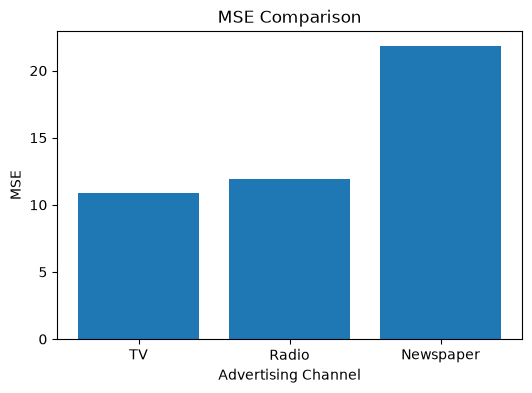

In [150]:
features=comparison["Feature"]
mse=comparison["MSE"]
plt.figure(figsize=(6,4))
plt.bar(features,mse)

plt.title("MSE Comparison")
plt.xlabel("Advertising Channel")
plt.ylabel("MSE")

plt.show()

## RMSE Comparison

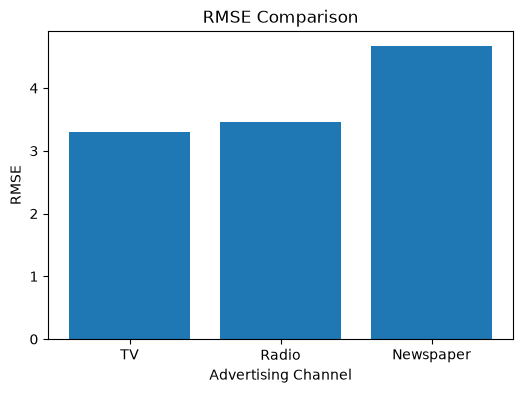

In [153]:
features=comparison["Feature"]
rmse=comparison["RMSE"]
plt.figure(figsize=(6,4))
plt.bar(features,rmse)

plt.title("RMSE Comparison")
plt.xlabel("Advertising Channel")
plt.ylabel("RMSE")

plt.show()